# Technique Comparison 


This notebook aims to compare and show the differences between layer strategies (last4 concat or penultimate) or antropy correction (raw vs corrected)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

In [15]:
# --- CONFIGURACIÓN DE ESTILO ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
colors = sns.color_palette("deep")

# Ajusta la ruta a donde tengas tu archivo parquet
file_path = '../data/phase3_results.parquet' 

try:
    # Usamos read_parquet en lugar de read_csv
    df = pd.read_parquet(file_path)
    print(f"✅ Archivo Parquet cargado: {len(df)} registros.")
except FileNotFoundError:
    print("❌ ERROR: No encuentro el archivo. Verifica la ruta o el nombre.")

# Aseguramos que la fecha esté en formato correcto (Parquet suele guardarlo bien, pero por seguridad)
if 'window_start_month' in df.columns:
    df['date'] = pd.to_datetime(df['window_start_month'])
    df = df.sort_values('date')

# --- 2. CONFIGURACIÓN DE LA COMPARATIVA ---
# Vamos a comparar usando el modelo DAPT (el adaptado a pandemia)
model_type = 'dapt' 

print(f"Comparando métricas para el modelo: {model_type.upper()}")
print("-" * 60)

✅ Archivo Parquet cargado: 11 registros.
Comparando métricas para el modelo: DAPT
------------------------------------------------------------



📈 GENERANDO BLOQUE A: Comparativa de Capas...


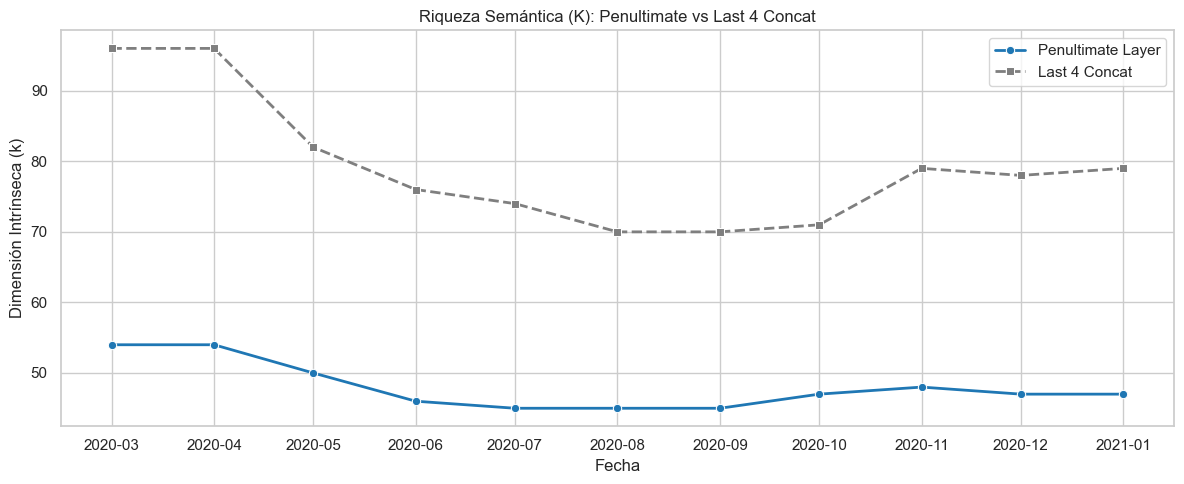

INTERPRETACIÓN A.1: Si 'Last 4' es mucho más alto, indica que captura más matices pero también más ruido.
La capa 'Penultimate' suele ser más estable para tareas semánticas globales.


In [20]:
# ==============================================================================
# BLOQUE A: ESTRATEGIA DE CAPAS (Penultimate vs Last4Concat).
# ==============================================================================

print("\n📈 GENERANDO BLOQUE A: Comparativa de Capas...")

# A.1. Riqueza Semántica (K - Dimensiones Intrínsecas)
# Columna Penultimate: k_dapt_penultimate
# Columna Last4: k_dapt_last4_concat

plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='date', y=f'k_{model_type}_penultimate', 
             label='Penultimate Layer', marker='o', linewidth=2, color='tab:blue')
sns.lineplot(data=df, x='date', y=f'k_{model_type}_last4_concat', 
             label='Last 4 Concat', marker='s', linestyle='--', linewidth=2, color='tab:gray')

plt.title(f'Riqueza Semántica (K): Penultimate vs Last 4 Concat')
plt.ylabel('Dimensión Intrínseca (k)')
plt.xlabel('Fecha')
plt.legend()
plt.tight_layout()
plt.show()

print("INTERPRETACIÓN A.1: Si 'Last 4' es mucho más alto, indica que captura más matices pero también más ruido.")
print("La capa 'Penultimate' suele ser más estable para tareas semánticas globales.")



La línea gris (Last4Concat) se mantiene muy alta (media $k \approx 79$), mientras que la azul (Penultimate) es significativamente más baja (media $k \approx 48$).

La última capa del modelo, al estar concatenada, retiene una enorme cantidad de información superficial y sintáctica (ruido), lo que infla la dimensionalidad. La capa penúltima actúa como un filtro de abstracción, comprimiendo el significado en menos dimensiones.

Penultimate ofrece una representación más "limpia" y semánticamente enfocada del concepto.

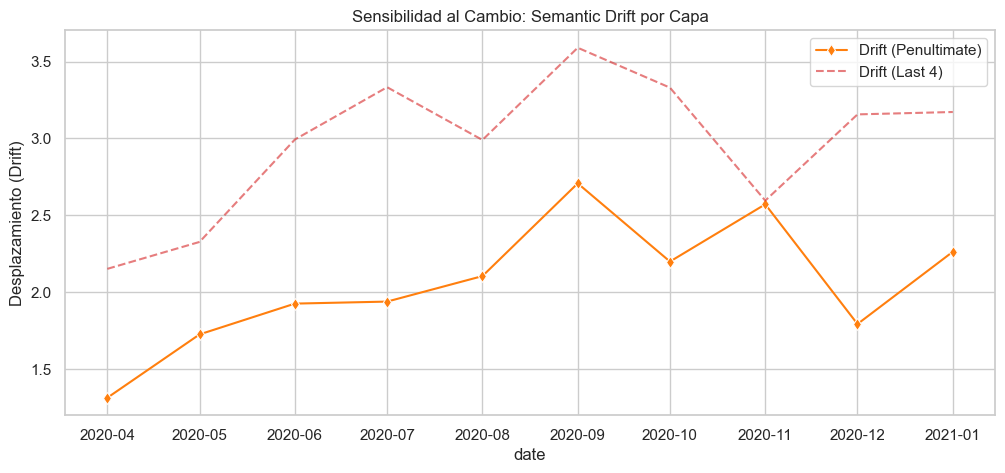

In [21]:
# A.2. Estabilidad Temporal (Drift)
# Columna Penultimate: drift_dapt_penultimate
# Columna Last4: drift_dapt_last4_concat

plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='date', y=f'drift_{model_type}_penultimate', 
             label='Drift (Penultimate)', color='tab:orange', marker='d')
sns.lineplot(data=df, x='date', y=f'drift_{model_type}_last4_concat', 
             label='Drift (Last 4)', color='tab:red', linestyle='--', alpha=0.6)

plt.title('Sensibilidad al Cambio: Semantic Drift por Capa')
plt.ylabel('Desplazamiento (Drift)')
plt.show()

La línea roja (Last4) tiene picos mucho más agresivos y una media de desplazamiento mayor (2.96) que la naranja (Penultimate, 2.05).

La capa Last4 es "nerviosa"; reacciona excesivamente a cambios menores en el fraseo de las noticias mes a mes. La capa Penultimate muestra una evolución más suave.

La estabilidad de Penultimate sugiere que los cambios que detecta son estructurales (profundos), no meramente variaciones de estilo.


📈 GENERANDO BLOQUE B: Raw vs Corrected...


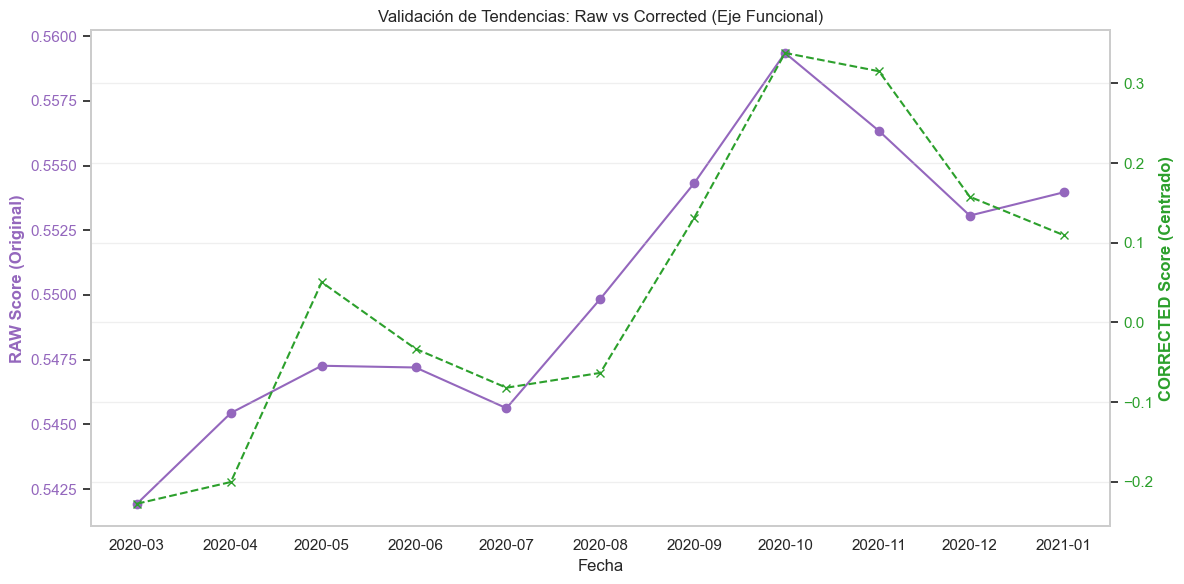

In [28]:
# ==============================================================================
# BLOQUE B: CORRECCIÓN DE ANISOTROPÍA (Raw vs Corrected)
# Objetivo: Demostrar que 'Corrected' no rompe los datos, solo los centra.
# ==============================================================================

print("\n📈 GENERANDO BLOQUE B: Raw vs Corrected...")

# Elegimos un eje para la prueba (ej. Funcional)
axis = 'funcional'
layer = 'penultimate'

# Construimos los nombres exactos de tus columnas
col_raw = f'centroid_proj_{axis}_{model_type}_{layer}_raw'
col_corr = f'centroid_proj_{axis}_{model_type}_{layer}_corrected'

# B.1. Tendencia Temporal (Doble Eje Y)
fig, ax1 = plt.subplots(figsize=(12, 6))

color_raw = 'tab:purple'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('RAW Score (Original)', color=color_raw, fontweight='bold')
ax1.plot(df['date'], df[col_raw], color=color_raw, label='RAW', marker='o')
ax1.tick_params(axis='y', labelcolor=color_raw)
ax1.grid(False) # Quitamos grid del eje 1 para no ensuciar

ax2 = ax1.twinx()  # Eje secundario
color_corr = 'tab:green'
ax2.set_ylabel('CORRECTED Score (Centrado)', color=color_corr, fontweight='bold')
ax2.plot(df['date'], df[col_corr], color=color_corr, label='CORRECTED', marker='x', linestyle='--')
ax2.tick_params(axis='y', labelcolor=color_corr)
ax2.grid(True, alpha=0.3)

plt.title(f'Validación de Tendencias: Raw vs Corrected (Eje {axis.capitalize()})')
fig.tight_layout()
plt.show()

Las líneas RAW (morado) y CORRECTED (verde) bailan juntas. Cuando una sube, la otra sube. Tienen la misma morfología.

La corrección matemática no está inventando datos ni distorsionando la realidad temporal. Simplemente está cambiando la escala (el eje Y) para centrarla, eliminando el sesgo positivo del modelo.

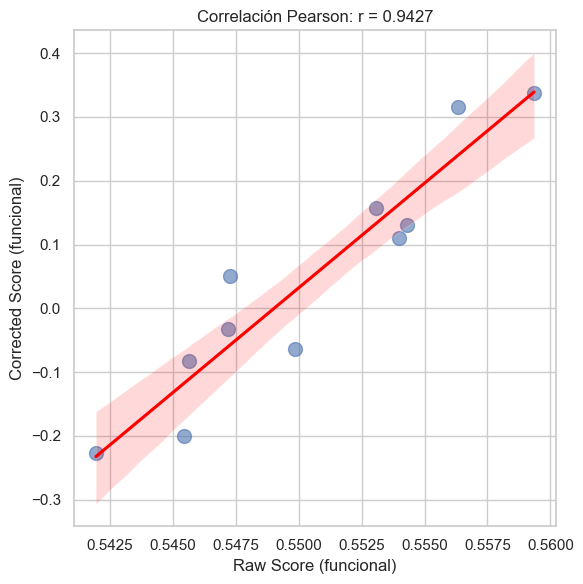

CONCLUSIÓN B: Una correlación de 0.9427 confirma que la corrección preserva la estructura relativa.


In [29]:
# B.2. Correlación de Pearson
# Calculamos qué tan parecidas son las curvas matemáticamente
corr, _ = pearsonr(df[col_raw], df[col_corr])

plt.figure(figsize=(6, 6))
sns.regplot(x=df[col_raw], y=df[col_corr], scatter_kws={'s':100, 'alpha':0.6}, line_kws={'color':'red'})
plt.title(f'Correlación Pearson: r = {corr:.4f}')
plt.xlabel(f'Raw Score ({axis})')
plt.ylabel(f'Corrected Score ({axis})')
plt.tight_layout()
plt.show()

print(f"CONCLUSIÓN B: Una correlación de {corr:.4f} confirma que la corrección preserva la estructura relativa.")

Una diagonal casi perfecta con $r \approx 0.94$. Existe una relación lineal fortísima entre los datos crudos y los corregidos.


📈 GENERANDO BLOQUE C: Comparativa de Ejes (La Historia)...


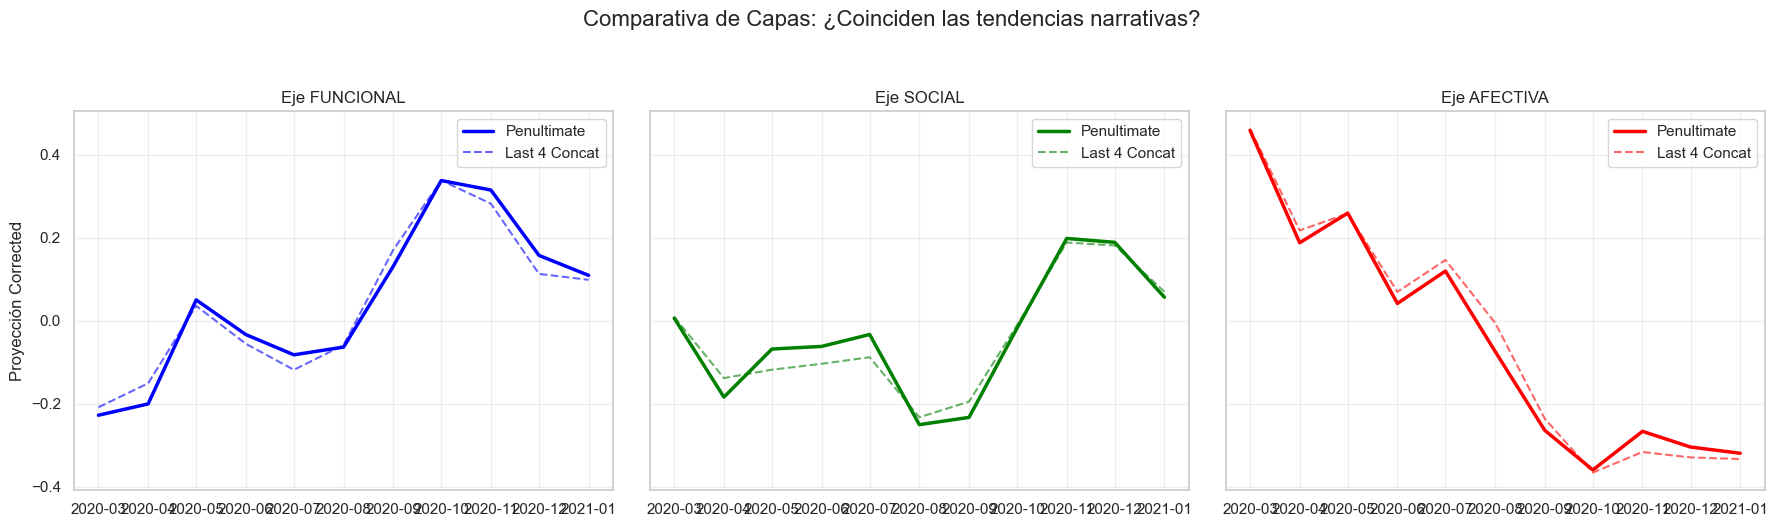

In [26]:
# ==============================================================================
# BLOQUE C: ANÁLISIS DE EJES (LA NARRATIVA)
# Objetivo: Ver si la historia (Funcional/Social/Afectiva) cambia según la técnica.
# ==============================================================================

print("\n📈 GENERANDO BLOQUE C: Comparativa de Ejes (La Historia)...")

axes_list = ['funcional', 'social', 'afectiva']
colors = {'funcional': 'blue', 'social': 'green', 'afectiva': 'red'}

# --- C.1 PENULTIMATE VS LAST4 (¿Cuenta la misma historia?) ---
# Usamos 'Corrected' para ambos para ser justos en la comparación de capas.
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, ax_name in enumerate(axes_list):
    col_pen = f'centroid_proj_{ax_name}_dapt_penultimate_corrected'
    col_last4 = f'centroid_proj_{ax_name}_dapt_last4_concat_corrected'
    
    # Plot Penultimate (Sólida)
    sns.lineplot(data=df, x='date', y=col_pen, ax=axs[i], 
                 color=colors[ax_name], linewidth=2.5, label='Penultimate')
    # Plot Last4 (Punteada)
    sns.lineplot(data=df, x='date', y=col_last4, ax=axs[i], 
                 color=colors[ax_name], linestyle='--', alpha=0.6, label='Last 4 Concat')
    
    axs[i].set_title(f'Eje {ax_name.upper()}')
    axs[i].set_xlabel('')
    if i == 0: axs[i].set_ylabel('Proyección Corrected')
    axs[i].grid(True, alpha=0.3)
    axs[i].legend()

plt.suptitle('Comparativa de Capas: ¿Coinciden las tendencias narrativas?', y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

Para los tres ejes (Funcional, Social, Afectivo), la línea sólida y la punteada son casi idénticas (Correlación > 0.97 en todos los casos).

Dado que ambas cuentan la misma historia nos decantariamos por Penultimate, ya que tiene menos ruido y es más sencilla como hemos estado viendo en todo el analysis. 

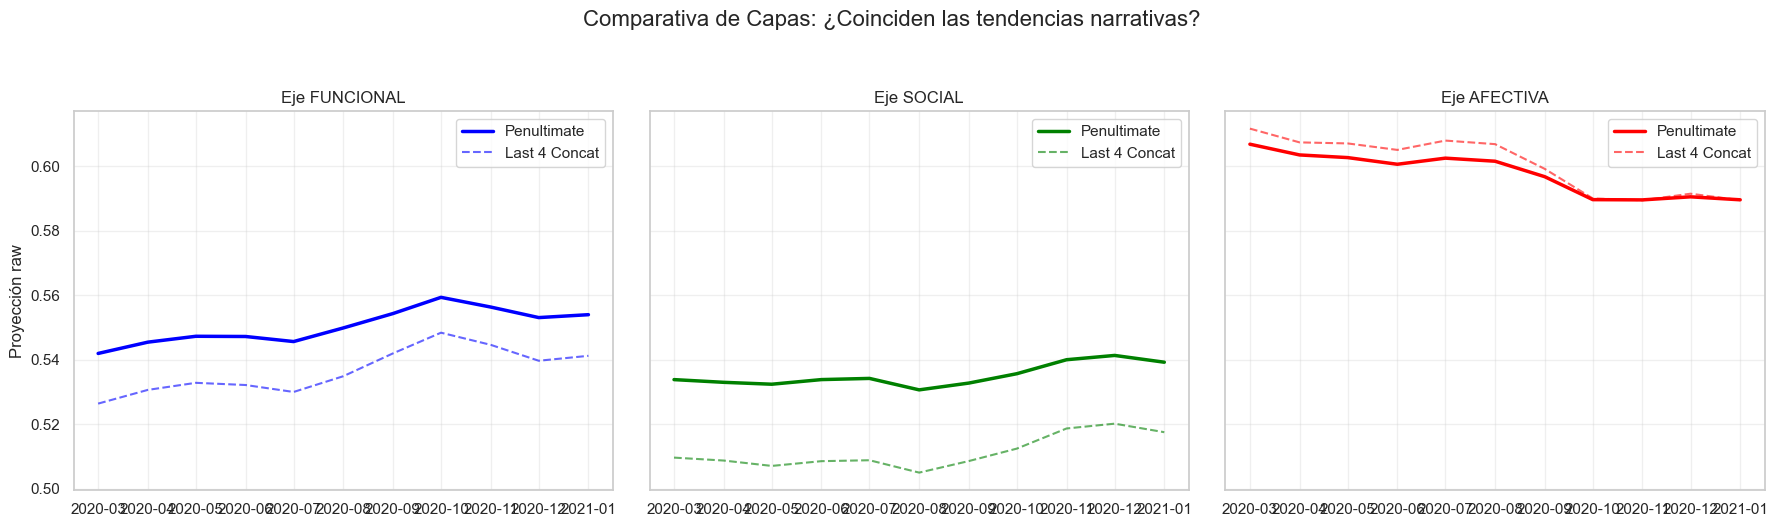

In [30]:
# --- C.1 PENULTIMATE VS LAST4 (¿Cuenta la misma historia?) ---
# Usamos 'raw' para ambos para ser justos en la comparación de capas.
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, ax_name in enumerate(axes_list):
    col_pen = f'centroid_proj_{ax_name}_dapt_penultimate_raw'
    col_last4 = f'centroid_proj_{ax_name}_dapt_last4_concat_raw'
    
    # Plot Penultimate (Sólida)
    sns.lineplot(data=df, x='date', y=col_pen, ax=axs[i], 
                 color=colors[ax_name], linewidth=2.5, label='Penultimate')
    # Plot Last4 (Punteada)
    sns.lineplot(data=df, x='date', y=col_last4, ax=axs[i], 
                 color=colors[ax_name], linestyle='--', alpha=0.6, label='Last 4 Concat')
    
    axs[i].set_title(f'Eje {ax_name.upper()}')
    axs[i].set_xlabel('')
    if i == 0: axs[i].set_ylabel('Proyección raw')
    axs[i].grid(True, alpha=0.3)
    axs[i].legend()

plt.suptitle('Comparativa de Capas: ¿Coinciden las tendencias narrativas?', y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

Para este plot usamos RAW, en este caso y al compararlo con el plot anterior, aunque sigue el mismo patrón nos decantamos por corrected ya que capturamos y vemos mejor los diferentes cambios a través del tiempo. Respecto a layer strategy nos seguimos decantando por penultimate basandonos en su sencillez.

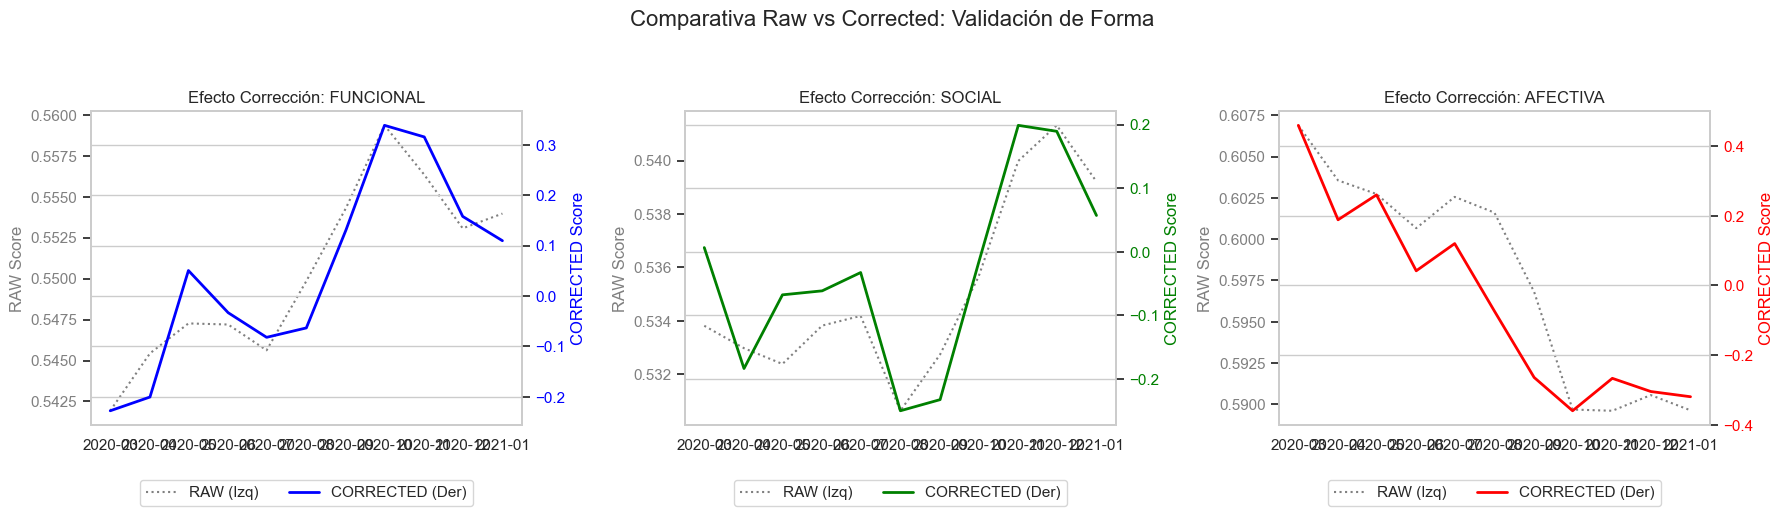

In [27]:
# --- C.2 RAW VS CORRECTED (¿Cambia la forma de la curva?) ---
# Nos centramos en Penultimate y vemos el efecto de la corrección.
fig, axs = plt.subplots(1, 3, figsize=(18, 5)) # No sharey porque las escalas son distintas

for i, ax_name in enumerate(axes_list):
    col_raw = f'centroid_proj_{ax_name}_dapt_penultimate_raw'
    col_corr = f'centroid_proj_{ax_name}_dapt_penultimate_corrected'
    
    # Eje Izquierdo (RAW)
    ax1 = axs[i]
    line1 = ax1.plot(df['date'], df[col_raw], color='gray', linestyle=':', label='RAW (Izq)')
    ax1.set_ylabel('RAW Score', color='gray')
    ax1.tick_params(axis='y', labelcolor='gray')
    
    # Eje Derecho (CORRECTED)
    ax2 = ax1.twinx()
    line2 = ax2.plot(df['date'], df[col_corr], color=colors[ax_name], linewidth=2, label='CORRECTED (Der)')
    ax2.set_ylabel('CORRECTED Score', color=colors[ax_name])
    ax2.tick_params(axis='y', labelcolor=colors[ax_name])
    
    ax1.set_title(f'Efecto Corrección: {ax_name.upper()}')
    ax1.grid(False) # Grid solo en uno para no ensuciar

    # Leyenda combinada (truco para matplotlib)
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.suptitle('Comparativa Raw vs Corrected: Validación de Forma', y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

Raw vs corrected, ambos presentan una morfología casi identica, siguiendo los mismos patrones. Ambas cuentan la misma historia. Si las curvas fueran muy distintas, significaría que la corrección está "rompiendo" los datos. Al ser iguales, significa que la corrección es segura y fiable.

La corrección de anisotropía actúa efectivamente como un re-escalado y centrado de la señal semántica, preservando intacta la estructura temporal y la narrativa evolutiva. Esto valida el uso de métricas corregidas para el reporte final, ya que ofrecen una interpretabilidad superior (centrada en el origen) sin sacrificar la fidelidad a los datos originales.


📈 GENERANDO BLOQUE D: Análisis de Entropía...


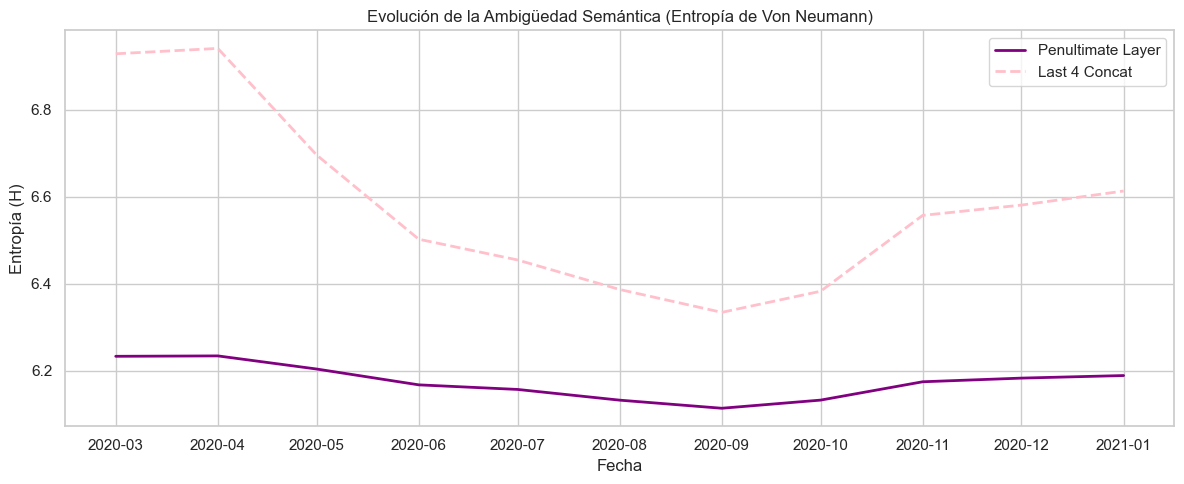

INTERPRETACIÓN ENTROPÍA: Una entropía alta indica que el término se usa en contextos muy diversos (significado difuso).
Una bajada en entropía sugiere que el discurso se está volviendo más enfocado o estandarizado.


In [25]:
# ==============================================================================
# BLOQUE D: ENTROPÍA (LA AMBIGÜEDAD)
# Objetivo: Ver qué tan "confuso" o "disperso" es el concepto.
# ==============================================================================

print("\n📈 GENERANDO BLOQUE D: Análisis de Entropía...")

# Comparativa de Entropía entre capas
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='date', y='entropy_dapt_penultimate', 
             label='Penultimate Layer', color='purple', linewidth=2)
sns.lineplot(data=df, x='date', y='entropy_dapt_last4_concat', 
             label='Last 4 Concat', color='pink', linestyle='--', linewidth=2)

plt.title('Evolución de la Ambigüedad Semántica (Entropía de Von Neumann)')
plt.ylabel('Entropía (H)')
plt.xlabel('Fecha')
plt.legend()
plt.tight_layout()
plt.show()

print("INTERPRETACIÓN ENTROPÍA: Una entropía alta indica que el término se usa en contextos muy diversos (significado difuso).")
print("Una bajada en entropía sugiere que el discurso se está volviendo más enfocado o estandarizado.")

La entropía de Penultimate es menor (6.17) que la de Last4 (6.58) y muestra una tendencia ligeramente descendente (pendiente negativa).

El discurso sobre salud mental se volvió menos ambiguo y más estandarizado con el tiempo. Last4 muestra más dispersión (más confusión).

De nuevo este plot solidifica y justifica nuestro razonamiento en cuanto a la decisión de elegir Penultimate.

## Conclusión General

Basándonos en la evidencia empírica de los gráficos anteriores, establecemos las siguientes decisiones metodológicas para el análisis final:

1. Elección de Layer Strategy: PENULTIMATE LAYER. 
2. Corrected vs Raw: CORRECTED

Basándonos en la evidencia empírica de los gráficos anteriores, establecemos las siguientes decisiones metodológicas para el análisis final:
1. Elección de Layer Strategy: PENULTIMATE LAYER

Decidimos extraer los embeddings de la penúltima capa del modelo DAPT basándonos en tres evidencias:
- Reducción de Ruido: Como demuestra el Plot A.1, la capa ``Last4Concat`` presenta una dimensionalidad intrínseca artificialmente alta ($k \approx 79$) debido a la retención de información sintáctica superficial. La capa ``Penultimate`` ($k \approx 48$) ofrece una abstracción semántica más eficiente.
- Estabilidad Temporal: El análisis de Drift (Plot A.2) revela que la capa final es inestable ante variaciones menores. La capa penúltima proporciona una trayectoria evolutiva más suave y coherente con procesos sociales graduales.
- Consistencia Narrativa: El Plot C.1 confirma que ambas estrategias narran la misma evolución histórica ($r > 0.97$ en todos los ejes). Por tanto, aplicamos el principio de parsimonia: elegimos la representación más simple y limpia (``Penultimate``) que no sacrifica información narrativa.

2. Elección de Technique: DUAL ANISOTROPY CORRECTION

Adoptamos la métrica corregida (Corrected) como estándar para nuestros reportes visuales:
- Robustez Validada: La alta correlación de Pearson ($r = 0.94$, Plot B.2) entre las señales ``Raw`` y ``Corrected`` demuestra que la corrección no introduce artefactos ni altera la tendencia temporal genuina de los datos.
- Rigor Geométrico: Aunque la tendencia es idéntica, la corrección elimina el sesgo anisotrópico inherente a los modelos Transformer (la tendencia de todos los vectores a agruparse en un cono estrecho), proporcionando distancias coseno geométricamente más precisas y centradas en el origen semántico real.

En resumen: Nuestro análisis se basará en **DAPT + Penultimate Layer + Corrected Metrics**, una combinación que garantiza la máxima pureza semántica, estabilidad temporal y rigor matemático.

---

Generando Gráfica de Centroides (La más importante)...


C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\1159604631.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=8)
C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\1159604631.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=8)
C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\1159604631.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=8)


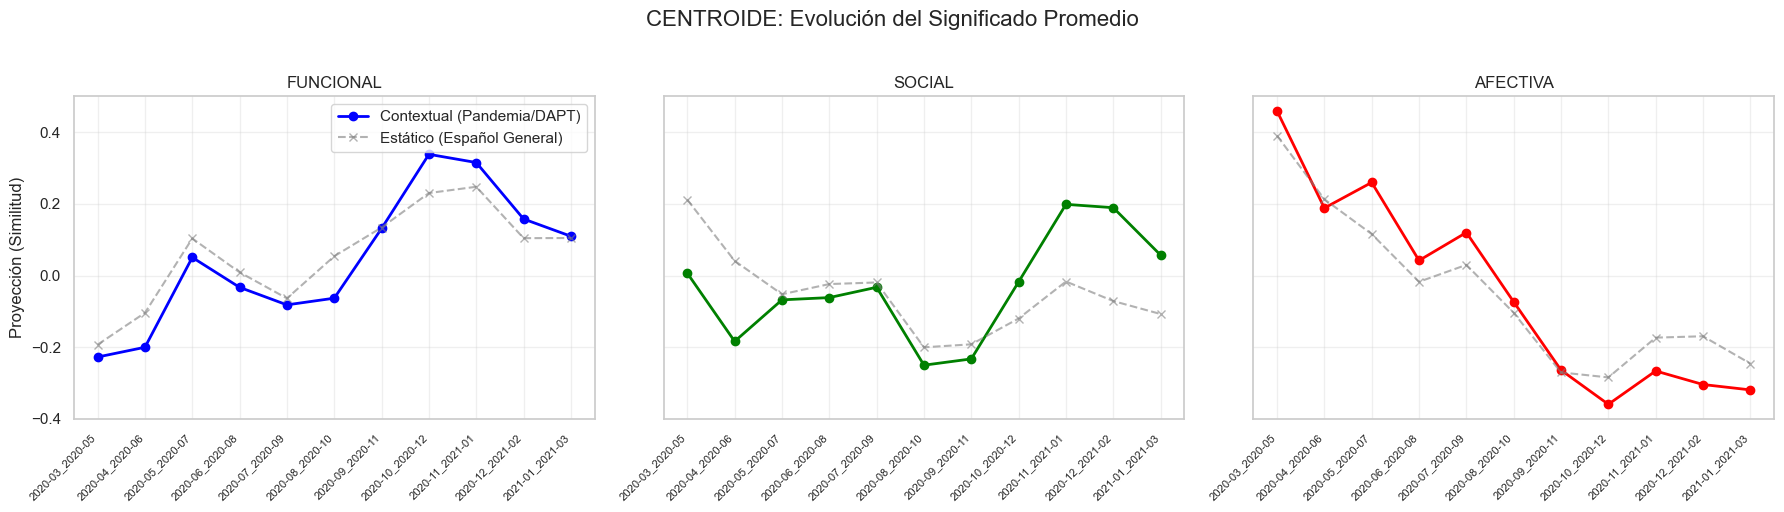


Generando Gráfica de Proyección de Subespacio (Equivalente a Dimensión 1)...


C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\1159604631.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=8)
C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\1159604631.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=8)
C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\1159604631.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=8)


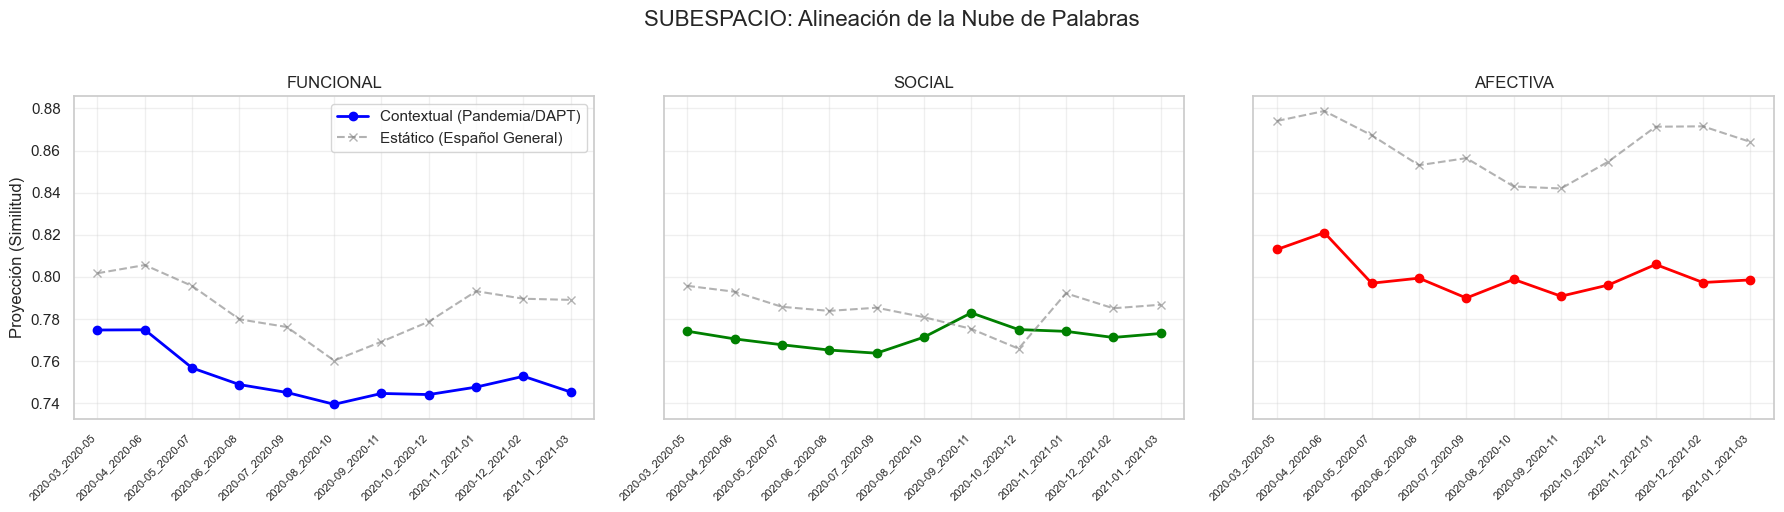

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. CREAR LA ETIQUETA DE TIEMPO (Estilo Supervisor: '2020-03_2020-05')
# Usamos las columnas que ya tienes en el CSV
df['window_label'] = df['window_start_month'] + "_" + df['window_end_month']

# Convertimos a formato fecha real para ordenar, pero usaremos el label para pintar
df['date_obj'] = pd.to_datetime(df['window_start_month'])
df = df.sort_values('date_obj')

# 2. PREPARAR LOS DATOS (EL TRUCO DE MAGIA)
# Vamos a crear las columnas que la función 'plot_projection_row' está buscando
# Mapeamos DAPT -> Contextual (Lo que pasó en las noticias)
# Mapeamos BASELINE -> Estático (El significado estándar en español)

for eje in ['funcional', 'social', 'afectiva']:
    # --- CENTROIDE (Mean) ---
    # La línea sólida (Contextual) será tu modelo DAPT
    df[f'score_centroid_{eje}_contextual'] = df[f'centroid_proj_{eje}_dapt_penultimate_corrected']
    # La línea discontinua (Estática) será tu modelo Baseline (Referencia)
    df[f'score_centroid_{eje}_static'] = df[f'centroid_proj_{eje}_baseline_penultimate_corrected']

    # --- DIMENSIÓN 1 (Usaremos tu Subspace Projection como proxy de Dim1) ---
    # Esto satisfará tu deseo de tener el plot de "Dimensión 1"
    df[f'score_dim1_{eje}_contextual'] = df[f'subspace_proj_{eje}_dapt_penultimate_corrected']
    df[f'score_dim1_{eje}_static'] = df[f'subspace_proj_{eje}_baseline_penultimate_corrected']

# 3. LA FUNCIÓN DE PLOTEO (Ligeramente adaptada para tu Eje X)
def plot_projection_row_custom(df, metric_prefix, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True) # Quitamos sharex para manejar etiquetas manuales
    
    dims = {
        'funcional': {'color': 'blue', 'ax': axes[0]},
        'social': {'color': 'green', 'ax': axes[1]},
        'afectiva': {'color': 'red', 'ax': axes[2]}
    }
    
    found_data = False
    
    for dim_name, props in dims.items():
        ax = props['ax']
        color = props['color']
        
        # Plot Contextual (Sólida - DAPT)
        col_ctx = f'{metric_prefix}{dim_name}_contextual'
        if col_ctx in df.columns:
            found_data = True
            ax.plot(df['window_label'], df[col_ctx], 
                    color=color, linestyle='-', marker='o', lw=2, label='Contextual (Pandemia/DAPT)')
        
        # Plot Estático (Discontinua - Baseline)
        col_sta = f'{metric_prefix}{dim_name}_static'
        if col_sta in df.columns:
            found_data = True
            ax.plot(df['window_label'], df[col_sta], 
                    color='gray', linestyle='--', marker='x', alpha=0.6, label='Estático (Español General)')
            
        ax.set_title(f"{dim_name.upper()}")
        ax.grid(True, alpha=0.3)
        
        # Rotar etiquetas del eje X para que se lean bien los rangos
        ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=8)
        
        if dim_name == 'funcional':
            ax.set_ylabel("Proyección (Similitud)")
            ax.legend()

    if found_data:
        plt.suptitle(f"{title_prefix}", fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No se encontraron datos para {title_prefix}")

# 4. EJECUTAR LOS PLOTS
print("Generando Gráfica de Centroides (La más importante)...")
plot_projection_row_custom(df, 'score_centroid_', 'CENTROIDE: Evolución del Significado Promedio')

print("\nGenerando Gráfica de Proyección de Subespacio (Equivalente a Dimensión 1)...")
plot_projection_row_custom(df, 'score_dim1_', 'SUBESPACIO: Alineación de la Nube de Palabras')

Generando Gráfica 1: CENTROIDES (Posición Relativa)


C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\3882548704.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\3882548704.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\3882548704.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)


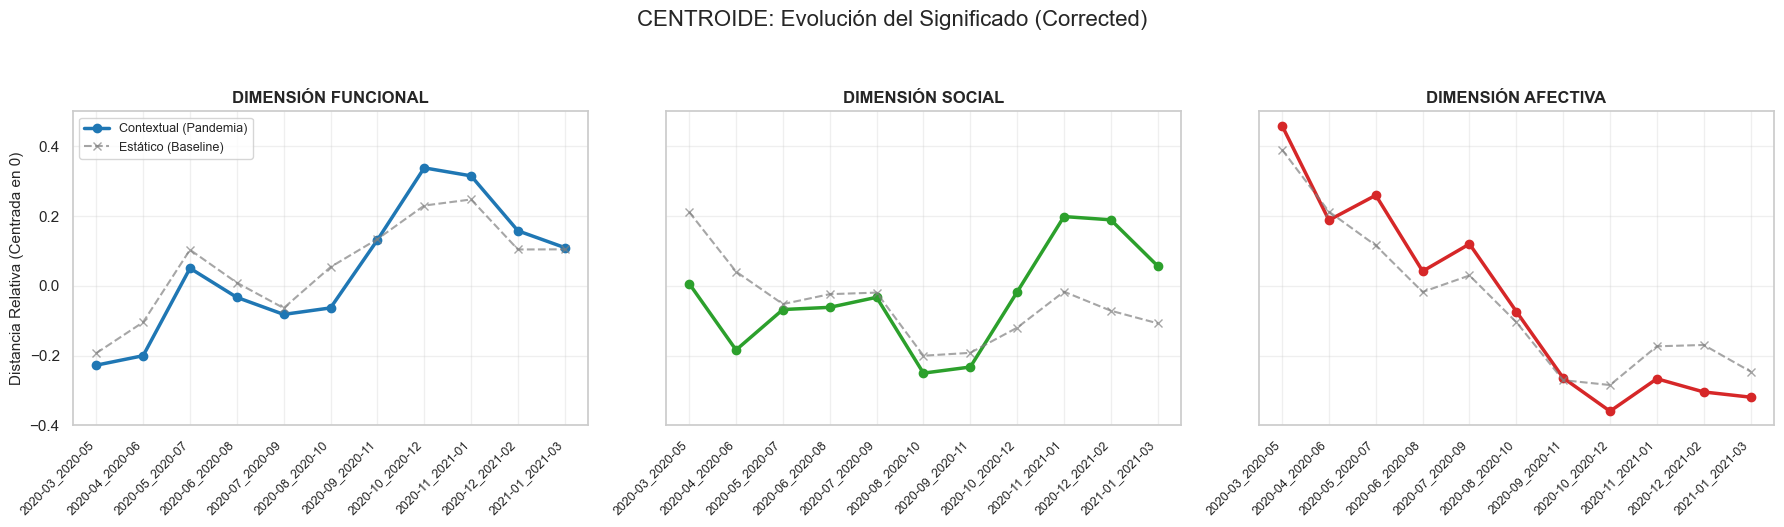


Generando Gráfica 2: SUBESPACIOS (Alineación Estructural)


C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\3882548704.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\3882548704.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\3882548704.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)


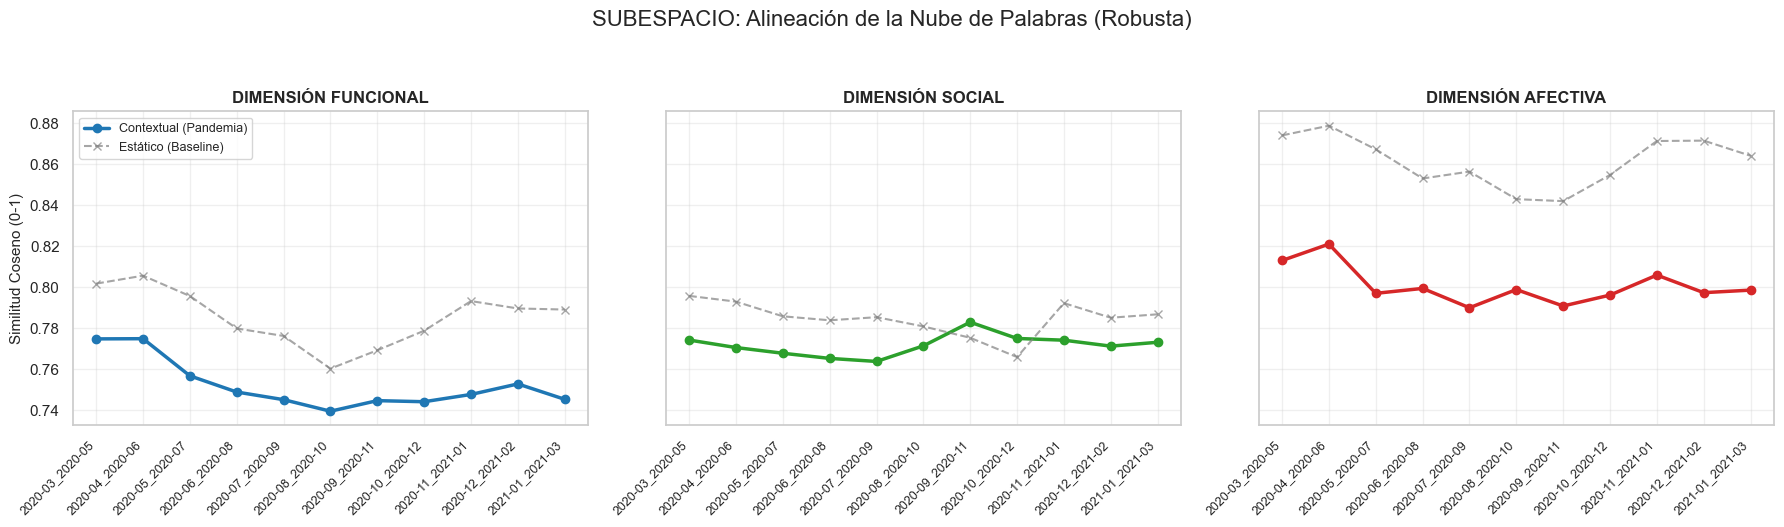

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configuración estética
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (18, 10)

# 1. PREPARACIÓN DE DATOS (Si no lo has hecho ya)
# Asegúrate de que df tiene las fechas ordenadas
df['date_obj'] = pd.to_datetime(df['window_start_month'])
df = df.sort_values('date_obj')
# Etiqueta estilo supervisor
df['window_label'] = df['window_start_month'] + "_" + df['window_end_month']

# 2. MAPEADO DE COLUMNAS (CORRECTED)
for eje in ['funcional', 'social', 'afectiva']:
    # --- CENTROIDE (Cambia mucho con la corrección) ---
    df[f'score_centroid_{eje}_contextual'] = df[f'centroid_proj_{eje}_dapt_penultimate_corrected']
    df[f'score_centroid_{eje}_static'] = df[f'centroid_proj_{eje}_baseline_penultimate_corrected']

    # --- SUBESPACIO (No cambia casi nada, es robusto) ---
    df[f'score_subspace_{eje}_contextual'] = df[f'subspace_proj_{eje}_dapt_penultimate_corrected']
    df[f'score_subspace_{eje}_static'] = df[f'subspace_proj_{eje}_baseline_penultimate_corrected']

# 3. FUNCIÓN DE PLOTEO MAESTRA
def plot_projection_row_custom(df, metric_prefix, title_prefix, ylabel):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    
    dims = {
        'funcional': {'color': 'tab:blue', 'ax': axes[0]},
        'social': {'color': 'tab:green', 'ax': axes[1]},
        'afectiva': {'color': 'tab:red', 'ax': axes[2]}
    }
    
    for dim_name, props in dims.items():
        ax = props['ax']
        color = props['color']
        
        # Plot Contextual (Sólida - DAPT)
        col_ctx = f'{metric_prefix}{dim_name}_contextual'
        if col_ctx in df.columns:
            ax.plot(df['window_label'], df[col_ctx], 
                    color=color, linestyle='-', marker='o', lw=2.5, label='Contextual (Pandemia)')
        
        # Plot Estático (Discontinua - Baseline)
        col_sta = f'{metric_prefix}{dim_name}_static'
        if col_sta in df.columns:
            ax.plot(df['window_label'], df[col_sta], 
                    color='gray', linestyle='--', marker='x', alpha=0.7, label='Estático (Baseline)')
            
        ax.set_title(f"DIMENSIÓN {dim_name.upper()}", fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
        
        # Línea de referencia en 0 (solo útil para Centroides Corrected)
        if "Centroide" in title_prefix:
            ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)

        if dim_name == 'funcional':
            ax.set_ylabel(ylabel, fontsize=11)
            ax.legend(loc='upper left', fontsize=9)

    plt.suptitle(f"{title_prefix}", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

# 4. EJECUCIÓN
print("Generando Gráfica 1: CENTROIDES (Posición Relativa)")
plot_projection_row_custom(df, 'score_centroid_', 
                          'CENTROIDE: Evolución del Significado (Corrected)', 
                          'Distancia Relativa (Centrada en 0)')

print("\nGenerando Gráfica 2: SUBESPACIOS (Alineación Estructural)")
plot_projection_row_custom(df, 'score_subspace_', 
                          'SUBESPACIO: Alineación de la Nube de Palabras (Robusta)', 
                          'Similitud Coseno (0-1)')

---

C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\739192375.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\739192375.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\739192375.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)


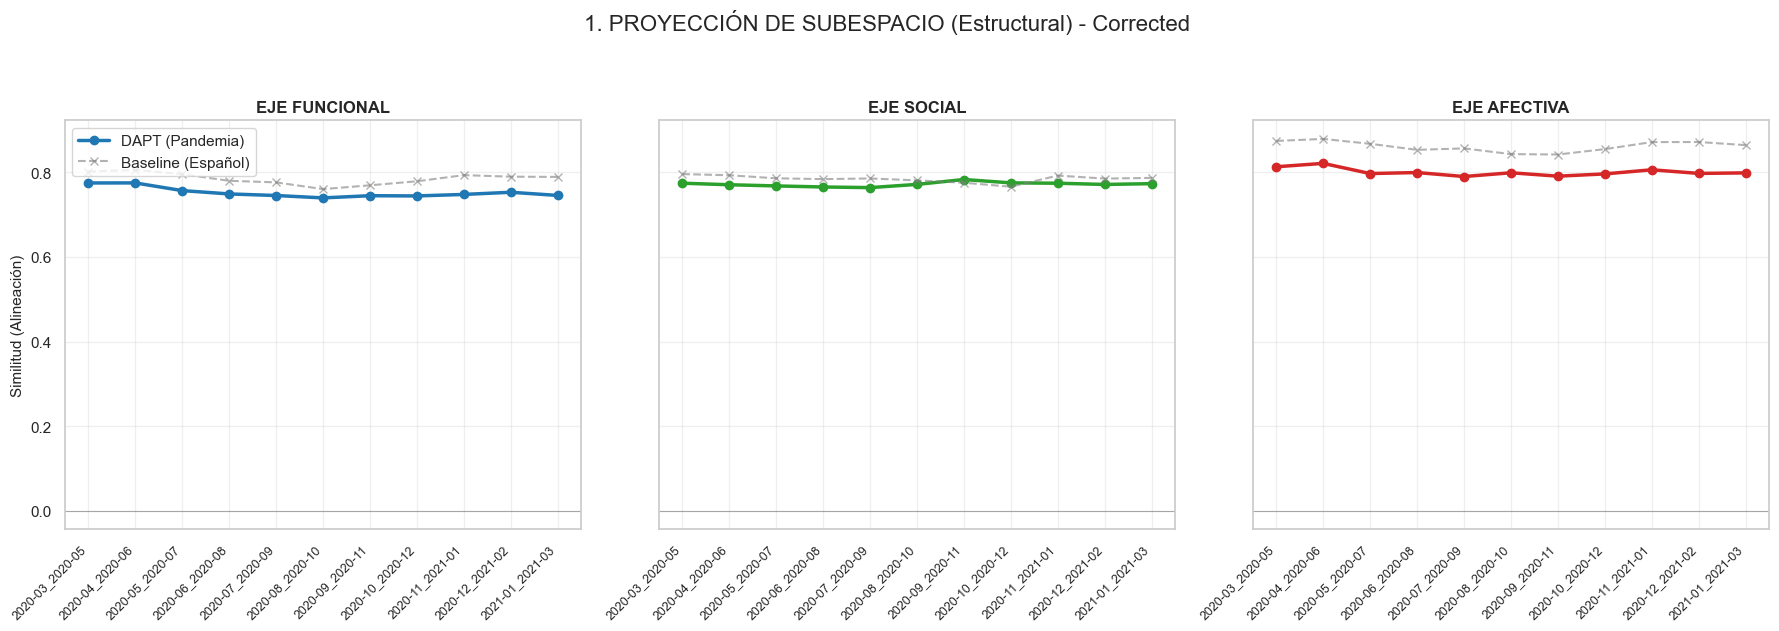

C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\739192375.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\739192375.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\739192375.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)


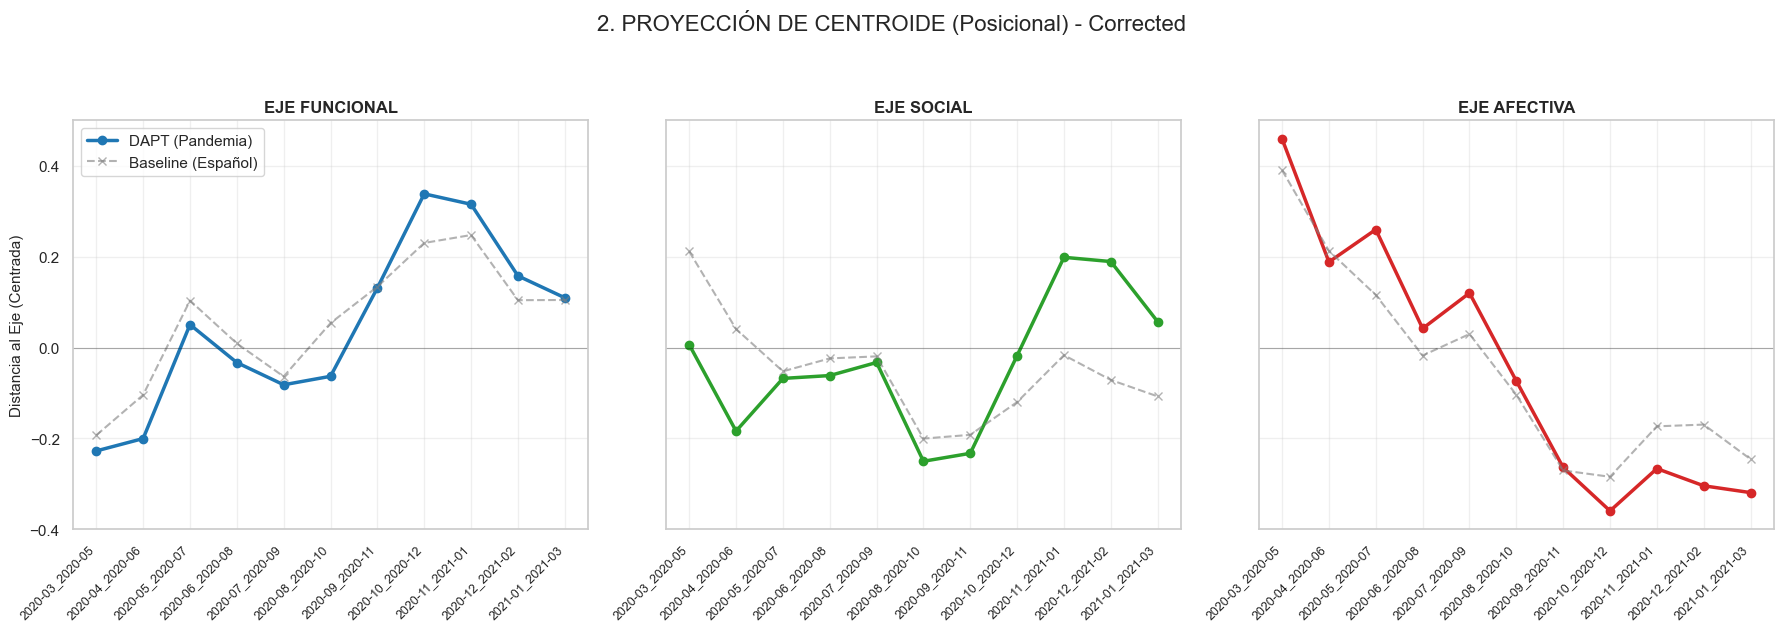

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os


# Ordenar por fecha para que el gráfico salga bien
if 'window_start_month' in df.columns:
    df['date_obj'] = pd.to_datetime(df['window_start_month'])
    df = df.sort_values('date_obj')
    # Crear etiqueta legible para el eje X
    df['window_label'] = df['window_start_month'] + "_" + df['window_end_month']

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (18, 6)

# --- 2. FUNCIÓN DE PLOTEO GENÉRICA ---
def plot_3_axes(df, metric_type, title_main, y_label):
    """
    metric_type: 'subspace_proj' o 'centroid_proj'
    """
    fig, axes = plt.subplots(1, 3, sharey=True)
    
    # Definimos los 3 ejes y sus colores
    dims = {
        'funcional': {'color': 'tab:blue', 'ax': axes[0]},
        'social':    {'color': 'tab:green', 'ax': axes[1]},
        'afectiva':  {'color': 'tab:red', 'ax': axes[2]}
    }
    
    for dim_name, props in dims.items():
        ax = props['ax']
        color = props['color']
        
        # 1. CONSTRUIMOS EL NOMBRE DE LA COLUMNA EXACTA QUE PEDISTE
        # Usamos: DAPT + PENULTIMATE + CORRECTED
        col_dapt = f'{metric_type}_{dim_name}_dapt_penultimate_corrected'
        
        # 2. (Opcional) AÑADIMOS EL BASELINE PARA TENER REFERENCIA
        # Usamos: BASELINE + PENULTIMATE + CORRECTED
        col_base = f'{metric_type}_{dim_name}_baseline_penultimate_corrected'
        
        # Ploteamos la línea DAPT (La importante)
        if col_dapt in df.columns:
            ax.plot(df['window_label'], df[col_dapt], 
                    color=color, marker='o', linewidth=2.5, label='DAPT (Pandemia)')
        else:
            print(f"⚠️ Falta columna: {col_dapt}")

        # Ploteamos la línea BASELINE (Referencia en gris)
        if col_base in df.columns:
            ax.plot(df['window_label'], df[col_base], 
                    color='gray', linestyle='--', marker='x', alpha=0.6, label='Baseline (Español)')

        # Decoración
        ax.set_title(f"EJE {dim_name.upper()}", fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
        
        # Línea 0 para referencia (importante en corrected)
        ax.axhline(0, color='black', linewidth=0.8, alpha=0.3)

        if dim_name == 'funcional':
            ax.set_ylabel(y_label, fontsize=11)
            ax.legend(loc='upper left')

    plt.suptitle(title_main, fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

# --- 3. EJECUTAR LOS PLOTS ---

# GRÁFICA 1: SUBESPACIO (Alineación Estructural)
# Espera valores altos (~0.7 - 0.8) incluso siendo corrected (por la invarianza traslacional)
plot_3_axes(df, 
            metric_type='subspace_proj', 
            title_main="1. PROYECCIÓN DE SUBESPACIO (Estructural) - Corrected",
            y_label="Similitud (Alineación)")

# GRÁFICA 2: CENTROIDE (Posición Semántica)
# Espera valores bajos o centrados en 0 (aquí sí se nota la corrección)
plot_3_axes(df, 
            metric_type='centroid_proj', 
            title_main="2. PROYECCIÓN DE CENTROIDE (Posicional) - Corrected",
            y_label="Distancia al Eje (Centrada)")

C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\3843604874.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\3843604874.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\3843604874.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)


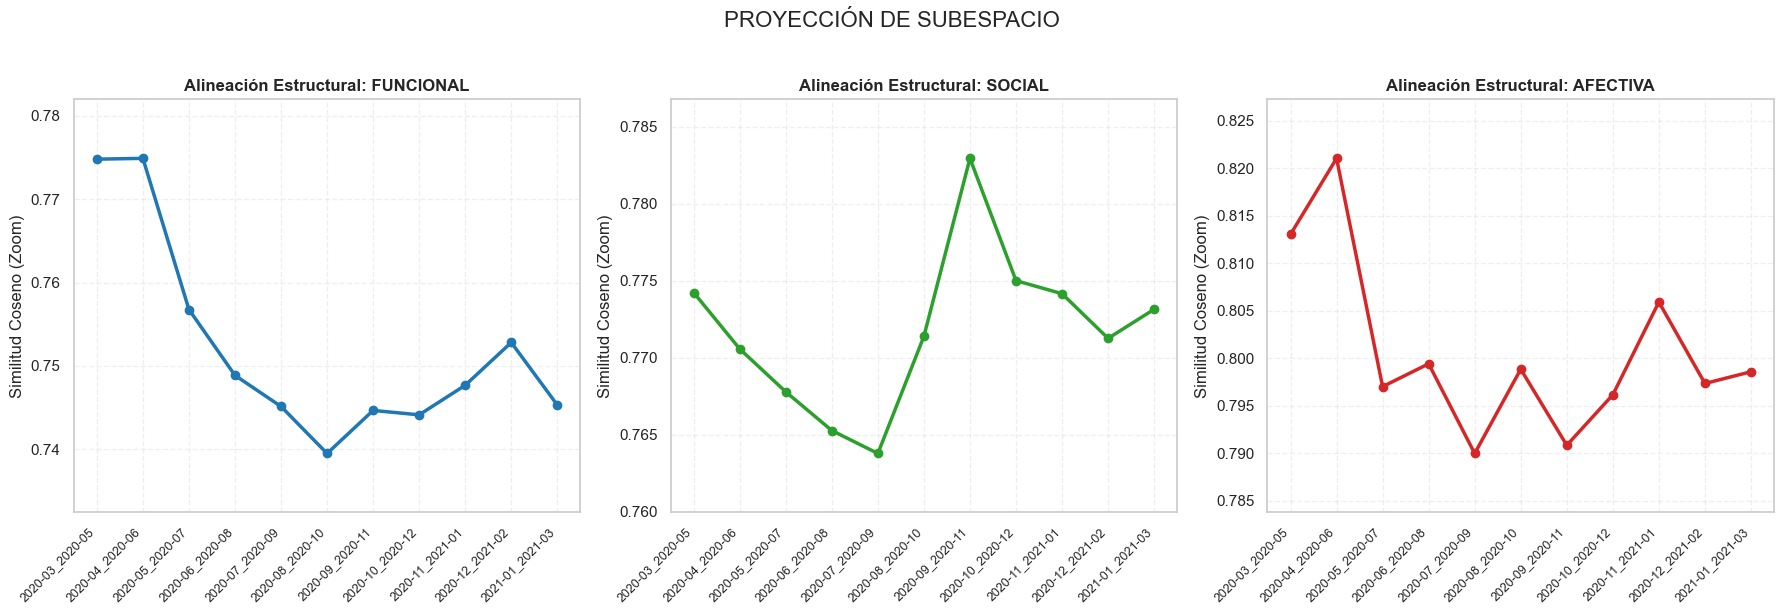

In [41]:
# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (18, 6)

# --- 2. CÁLCULO DEL IMPACTO RELATIVO (Opción B) ---
# Restamos el Baseline para eliminar el "0.8" base y ver solo el movimiento.
for eje in ['funcional', 'social', 'afectiva']:
    col_dapt = f'subspace_proj_{eje}_dapt_penultimate_corrected'
    col_base = f'subspace_proj_{eje}_baseline_penultimate_corrected'
    
    # Delta = Pandemia - Normalidad
    df[f'impacto_relativo_{eje}'] = df[col_dapt] - df[col_base]

# --- 3. PLOT CON ZOOM AUTOMÁTICO ---
def plot_subspace_simple_zoom(df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) # Sharey=False permite zoom individual
    
    dims = {
        'funcional': {'color': 'tab:blue', 'ax': axes[0]},
        'social':    {'color': 'tab:green', 'ax': axes[1]},
        'afectiva':  {'color': 'tab:red', 'ax': axes[2]}
    }
    
    for dim_name, props in dims.items():
        ax = props['ax']
        color = props['color']
        
        # COLUMNA MAESTRA (Corrected)
        col_dapt = f'subspace_proj_{dim_name}_dapt_penultimate_corrected'
        
        # Ploteamos
        ax.plot(df['window_label'], df[col_dapt], 
                color=color, marker='o', linewidth=2.5, label='Alineación (DAPT)')
        
        # Configuración
        ax.set_title(f"Alineación Estructural: {dim_name.upper()}", fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
        ax.set_ylabel("Similitud Coseno (Zoom)")
        
        # EL TRUCO: NO ponemos set_ylim(0,1). Dejamos que matplotlib ajuste.
        # Solo añadimos un pequeño margen para que no toque los bordes
        y_min, y_max = df[col_dapt].min(), df[col_dapt].max()
        margin = (y_max - y_min) * 0.2
        ax.set_ylim(y_min - margin, y_max + margin)

    plt.suptitle("PROYECCIÓN DE SUBESPACIO", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

plot_subspace_simple_zoom(df)

C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\21644205.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\21644205.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
C:\Users\alvar\AppData\Local\Temp\ipykernel_31652\21644205.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)


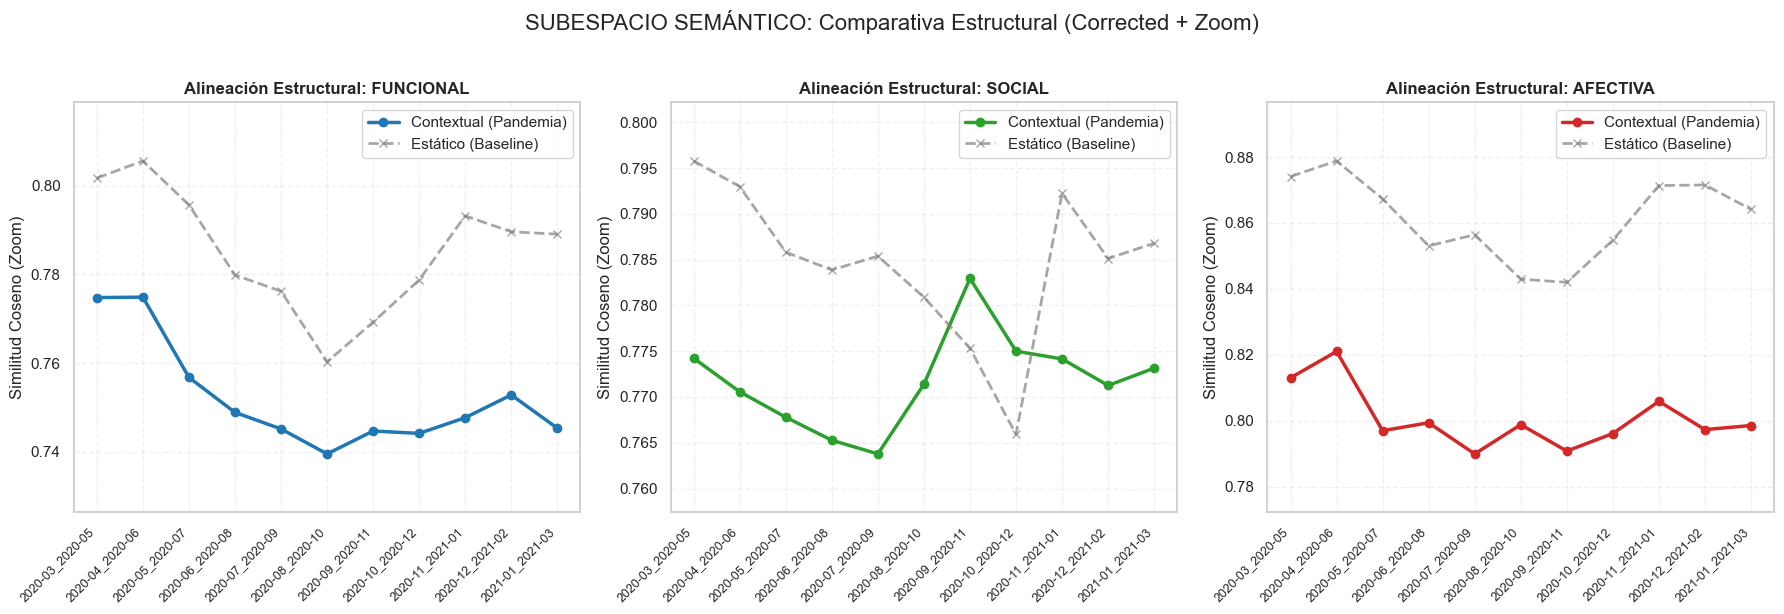

In [43]:
def plot_subspace_comparison_zoom(df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) # Zoom individual
    
    dims = {
        'funcional': {'color': 'tab:blue', 'ax': axes[0]},
        'social':    {'color': 'tab:green', 'ax': axes[1]},
        'afectiva':  {'color': 'tab:red', 'ax': axes[2]}
    }
    
    for dim_name, props in dims.items():
        ax = props['ax']
        color = props['color']
        
        # DEFINIR COLUMNAS
        col_dapt = f'subspace_proj_{dim_name}_dapt_penultimate_corrected'
        col_base = f'subspace_proj_{dim_name}_baseline_penultimate_corrected'
        
        # 1. Plot DAPT (Contextual - Pandemia)
        if col_dapt in df.columns:
            ax.plot(df['window_label'], df[col_dapt], 
                    color=color, marker='o', linewidth=2.5, label='Contextual (Pandemia)')
        
        # 2. Plot BASELINE (Estático - Español General)
        if col_base in df.columns:
            ax.plot(df['window_label'], df[col_base], 
                    color='gray', linestyle='--', marker='x', alpha=0.7, linewidth=2, label='Estático (Baseline)')
        
        # CONFIGURACIÓN
        ax.set_title(f"Alineación Estructural: {dim_name.upper()}", fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=9)
        ax.set_ylabel("Similitud Coseno (Zoom)")
        ax.legend()
        
        # ZOOM INTELIGENTE (Adaptado a las dos líneas)
        # Buscamos el min y max de AMBAS líneas para que ninguna se corte
        vals_dapt = df[col_dapt] if col_dapt in df.columns else pd.Series([0.7])
        vals_base = df[col_base] if col_base in df.columns else pd.Series([0.7])
        
        y_min = min(vals_dapt.min(), vals_base.min())
        y_max = max(vals_dapt.max(), vals_base.max())
        
        # Añadimos un margen del 10% arriba y abajo para que respire
        margin = (y_max - y_min) * 0.2 if y_max != y_min else 0.01
        ax.set_ylim(y_min - margin, y_max + margin)

    plt.suptitle("SUBESPACIO SEMÁNTICO: Comparativa Estructural (Corrected + Zoom)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Ejecutar
plot_subspace_comparison_zoom(df)

---

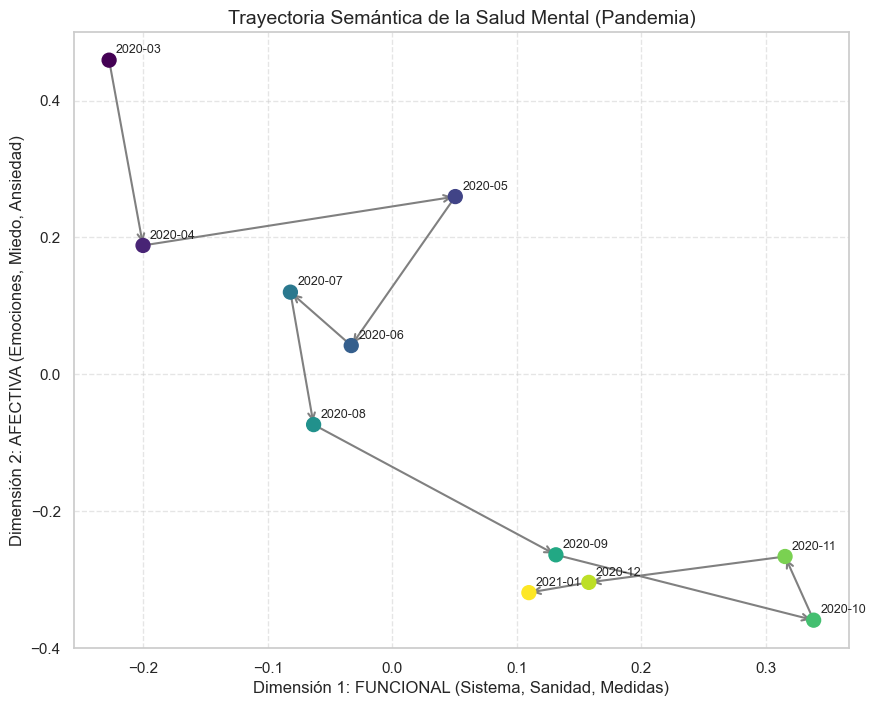

Interpretación: Observa la dirección de las flechas. Si viajan de arriba a la derecha, significa que el discurso perdió carga emocional y ganó pragmatismo sanitario.


In [35]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Definimos el modelo que vamos a usar
modelo = 'dapt_penultimate'

# Definimos qué será nuestro "Eje 1" y "Eje 2"
# Eje X: Evolución hacia lo Funcional (Sistema, médico, tratamientos)
col_x = f'centroid_proj_funcional_{modelo}_corrected'
# Eje Y: Evolución hacia lo Afectivo (Emociones, miedo, tristeza)
col_y = f'centroid_proj_afectiva_{modelo}_corrected'

if col_x in df.columns and col_y in df.columns:
    plt.figure(figsize=(10, 8))
    
    # Extraemos los datos
    x = df[col_x].values
    y = df[col_y].values
    fechas = df['window_start_month'].values
    
    # Creamos un gradiente de color para ver el paso del tiempo (de claro a oscuro)
    colors = cm.viridis(np.linspace(0, 1, len(fechas)))
    
    # Dibujamos los puntos
    plt.scatter(x, y, c=colors, s=100, zorder=3)
    
    # Conectamos los puntos con flechas para ver la dirección del tiempo
    for i in range(len(fechas)-1):
        plt.annotate('', xy=(x[i+1], y[i+1]), xytext=(x[i], y[i]),
                     arrowprops=dict(arrowstyle="->", color="gray", lw=1.5), zorder=2)
        
    # Ponemos las etiquetas de las fechas en cada punto
    for i, txt in enumerate(fechas):
        plt.annotate(txt, (x[i], y[i]), xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    # Configuración estética
    plt.title('Trayectoria Semántica de la Salud Mental (Pandemia)', fontsize=14)
    plt.xlabel('Dimensión 1: FUNCIONAL (Sistema, Sanidad, Medidas)', fontsize=12)
    plt.ylabel('Dimensión 2: AFECTIVA (Emociones, Miedo, Ansiedad)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5, zorder=1)
    
    plt.show()
    
    print("Interpretación: Observa la dirección de las flechas. Si viajan de arriba a la derecha, significa que el discurso perdió carga emocional y ganó pragmatismo sanitario.")
else:
    print(f"Error: No encuentro las columnas {col_x} o {col_y}")